# Quantum Process Tomography

Quantum Process Tomography (QPT) is the "gold standard" experimental technique used to fully characterize an unknown quantum process or operation (such as a quantum gate) by reconstructing its action on a quantum system.

`Key Aspects of Quantum Process Tomography`:
- **Purpose**: QPT is used to measure the quality of quantum gates and diagnose errors in quantum hardware. It determines how closely an experimental gate matches the ideal gate.

- **Methodology**: The technique involves preparing a set of known input states ($\rho_i$), applying the unknown process ($E$), and then performing quantum state tomography on the resulting outputs ($E(\rho_i)$).

- **Reconstruction**: The measurement data is used to reconstruct the quantum operation, typically represented by a $\chi$-matrix or a Choi/Chi matrix, which describes the process, such as a quantum channel or a noisy gate.

The word tomography literally means "slice-drawing" or "section-writing"

Used in Quantum Tomography to reconstruct the state or process of quantum systems.

In [2]:
import numpy as np
from qutip import (qeye, qpt, qpt_plot_combined, sigmax, sigmaz, sigmay,
                   spost, spre)     # Superoperator formed from post/pre-multiplication by operator A.

from qutip_qip.operations import (cnot, fredkin, iswap, phasegate, snot,
                                  sqrtiswap, swap, toffoli)
# qutip-qip (Quantum Information Processing) is a QuTiP package used to 
# simulate quantum circuits and quantum hardware dynamics

%matplotlib inline

| Gate            | Qiskit Name           | Function / Matrix                                                                                                                         | Purpose                                                                                   | Key Use Cases                                                                                                                                                   |
| --------------- | --------------------- | ----------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **`cnot`**      | `CXGate` / `cx`       | Flips target qubit if control is \|1⟩<br>$\begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$ | **Entanglement generation**; fundamental 2-qubit gate for creating correlated states      | • Bell state preparation<br>• Quantum teleportation<br>• QEC (stabilizer measurements)<br>• Universal gate set component                                        |
| **`fredkin`**   | `CSwapGate` / `cswap` | Swaps two qubits if control is \|1⟩<br>(3-qubit gate)                                                                                     | **Conditional routing** of quantum information                                            | • Reversible computing<br>• Quantum multiplexing<br>• Comparator circuits<br>• Quantum RAM proposals                                                            |
| **`iswap`**     | `iSwapGate` / `iswap` | Swaps qubits with $i$ phase on \|11⟩<br>$\begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & i & 0 \\ 0 & i & 0 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$  | **Native gate for superconducting qubits**; natural interaction in transmon architectures | • Google Sycamore native operations<br>• XY-interaction simulation<br>• Fermionic swap networks<br>• Efficient state preparation                                |
| **`phasegate`** | `PhaseGate` / `p`     | Adds phase $e^{i\theta}$ to \|1⟩<br>$\begin{pmatrix} 1 & 0 \\ 0 & e^{i\theta} \end{pmatrix}$                                              | **Arbitrary phase rotation** on the Bloch sphere Z-axis                                   | • General $R_z(\theta)$ rotations<br>• QPE (Quantum Phase Estimation)<br>• Z-basis encoding<br>• S ($\theta=\pi/2$) and T ($\theta=\pi/4$) gates                |
| **`snot`**      | `XGate` / `x`         | Bit-flip: \|0⟩ ↔ \|1⟩<br>$\begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}$                                                                   | **Classical NOT analog**; fundamental Pauli operation                                     | • Bit inversion<br>• Basis change (X ↔ Z)<br>• Error correction (X-type syndromes)<br>• Oracle construction (Grover's)                                          |
| **`sqrtiswap`** | Custom `UnitaryGate`  | Square root of iSWAP<br>$\sqrt{\text{iSWAP}}$                                                                                             | **Partial swap with entangling**; creates tunable entanglement                            | • Continuous-time quantum walks<br>• Fermionic simulation (trotter steps)<br>• Native superconducting gate sequences<br>• Approximate SWAP for shallow circuits |
| **`swap`**      | `SwapGate` / `swap`   | Exchanges two qubit states<br>$\begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 0 & 1 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \end{pmatrix}$            | **Qubit reordering** without entangling                                                   | • Topology-constrained routing (IBM, ion traps)<br>• Qubit relabeling in circuits<br>• Implementing as 3 CNOTs<br>• Network/qubit shuffling                     |
| **`toffoli`**   | `CCXGate` / `ccx`     | CCNOT: flips target if both controls are \|1⟩<br>(3-qubit gate)                                                                           | **Universal reversible logic**; classical computation in quantum                          | • Reversible arithmetic (adders, multipliers)<br>• Grover's oracle construction<br>• Error correction (T-state distillation)<br>• Quantum logic synthesis       |


In [13]:
"""
Plot the process tomography matrices for some 1, 2, and 3-qubit qubit gates.
"""
gates = [
    ["C-NOT", cnot()],
    ["SWAP", swap()],
    ["$i$SWAP", iswap()],
    [r"$\sqrt{i\mathrm{SWAP}}$", sqrtiswap()],
    ["S-NOT", snot()],
    [r"$\pi/2$ phase gate", phasegate(np.pi / 2)],
    ["Toffoli", toffoli()],
    ["Fredkin", fredkin()],
]


In [21]:
def plt_qpt_gate(gate, figsize=(8, 6)):
    
    name = gate[0]
    U_psi = gate[1]

    N = len(U_psi.dims[0])      # number of qubits

    # Create a superoperator for the density matrix
    # transformation rho = U_psi * rho_0 * U_psi.dag()
    U_rho = spre(U_psi) * spost(U_psi.dag())

    # operator basis for the process tomography
    op_basis = [[qeye(2), sigmax(), sigmay(), sigmaz()] for i in range(N)]

    # labels for operator basis
    op_label = [["$i$", "$x$", "$y$", "$z$"] for i in range(N)]

    # Calculate the chi matrix
    chi = qpt(U_rho, op_basis)

    # Visualize the chi matrix
    fig, ax = qpt_plot_combined(chi, op_label, name, figsize=figsize)

    ax.set_title(name)

    return fig, ax

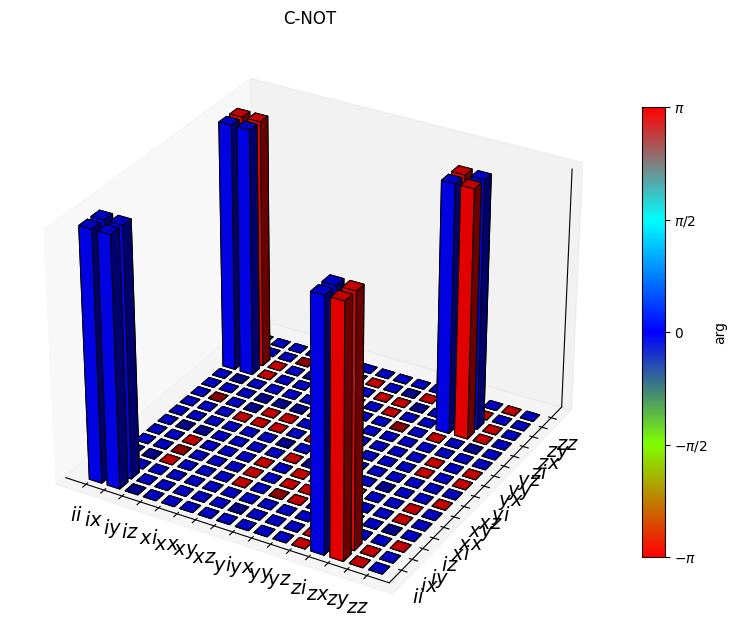

In [24]:
plt_qpt_gate(gates[0]);

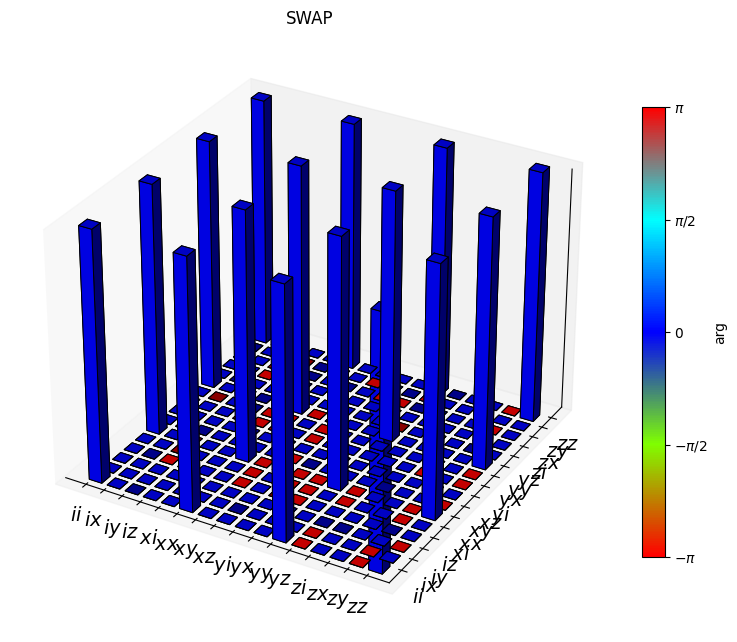

In [25]:
plt_qpt_gate(gates[1]);

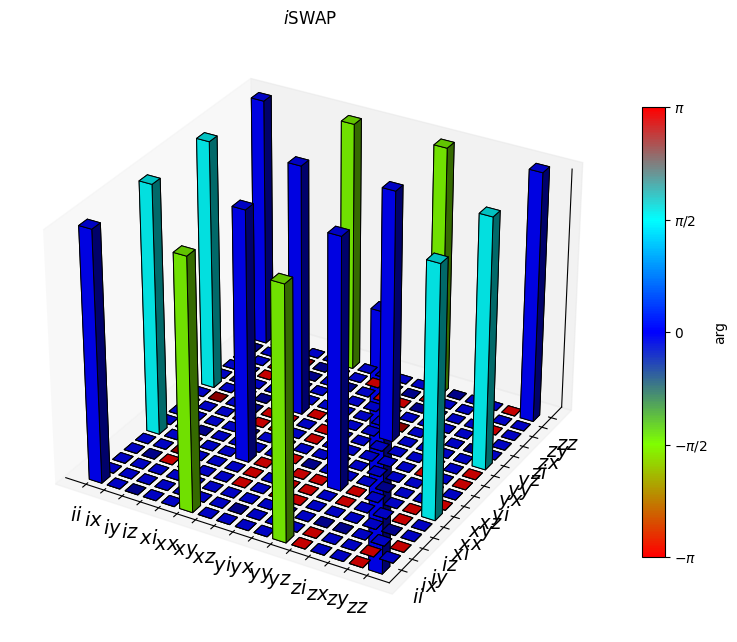

In [26]:
plt_qpt_gate(gates[2]);

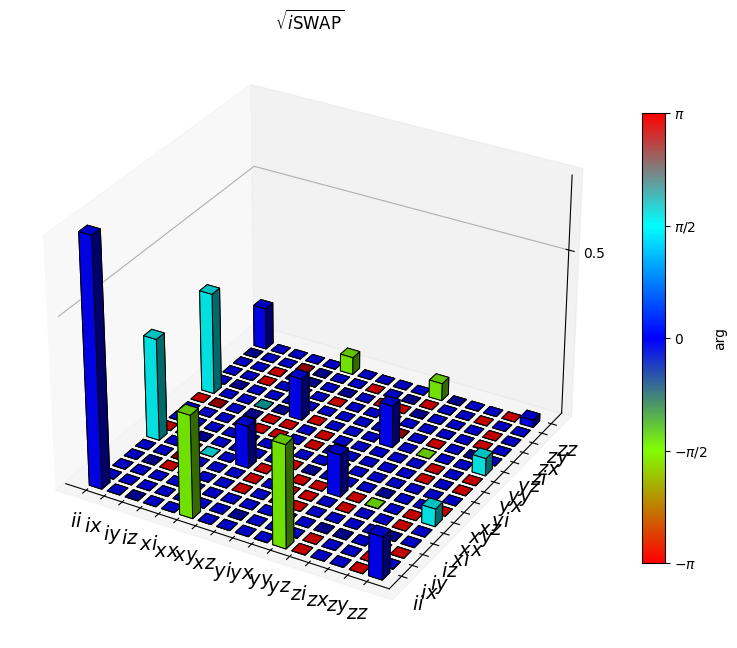

In [27]:
plt_qpt_gate(gates[3]);

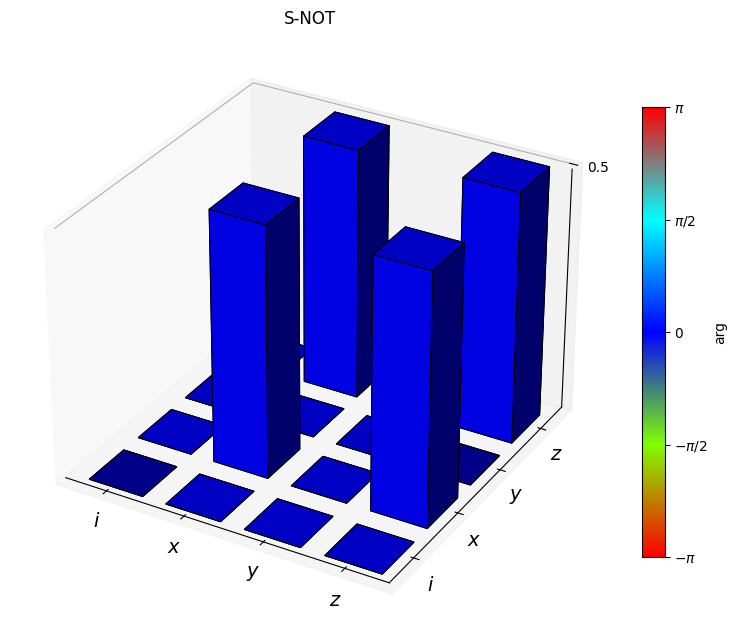

In [30]:
plt_qpt_gate(gates[4]);

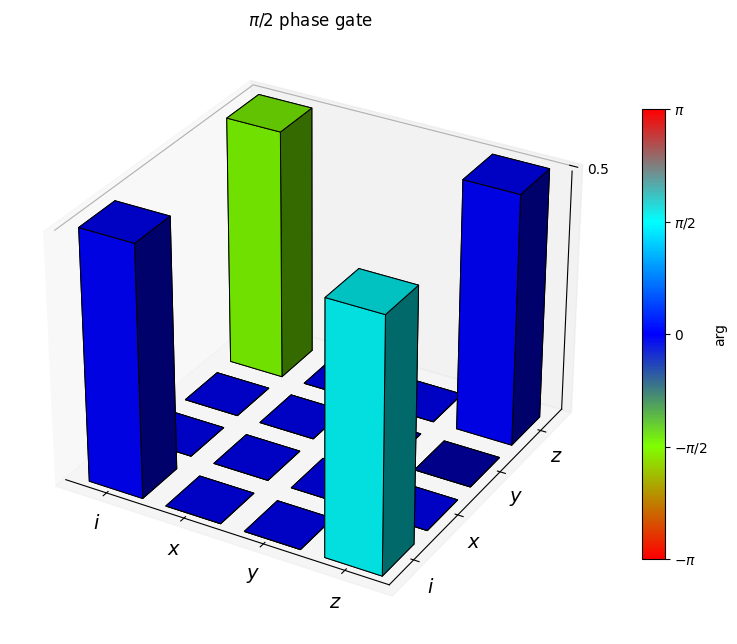

In [31]:
plt_qpt_gate(gates[5]);

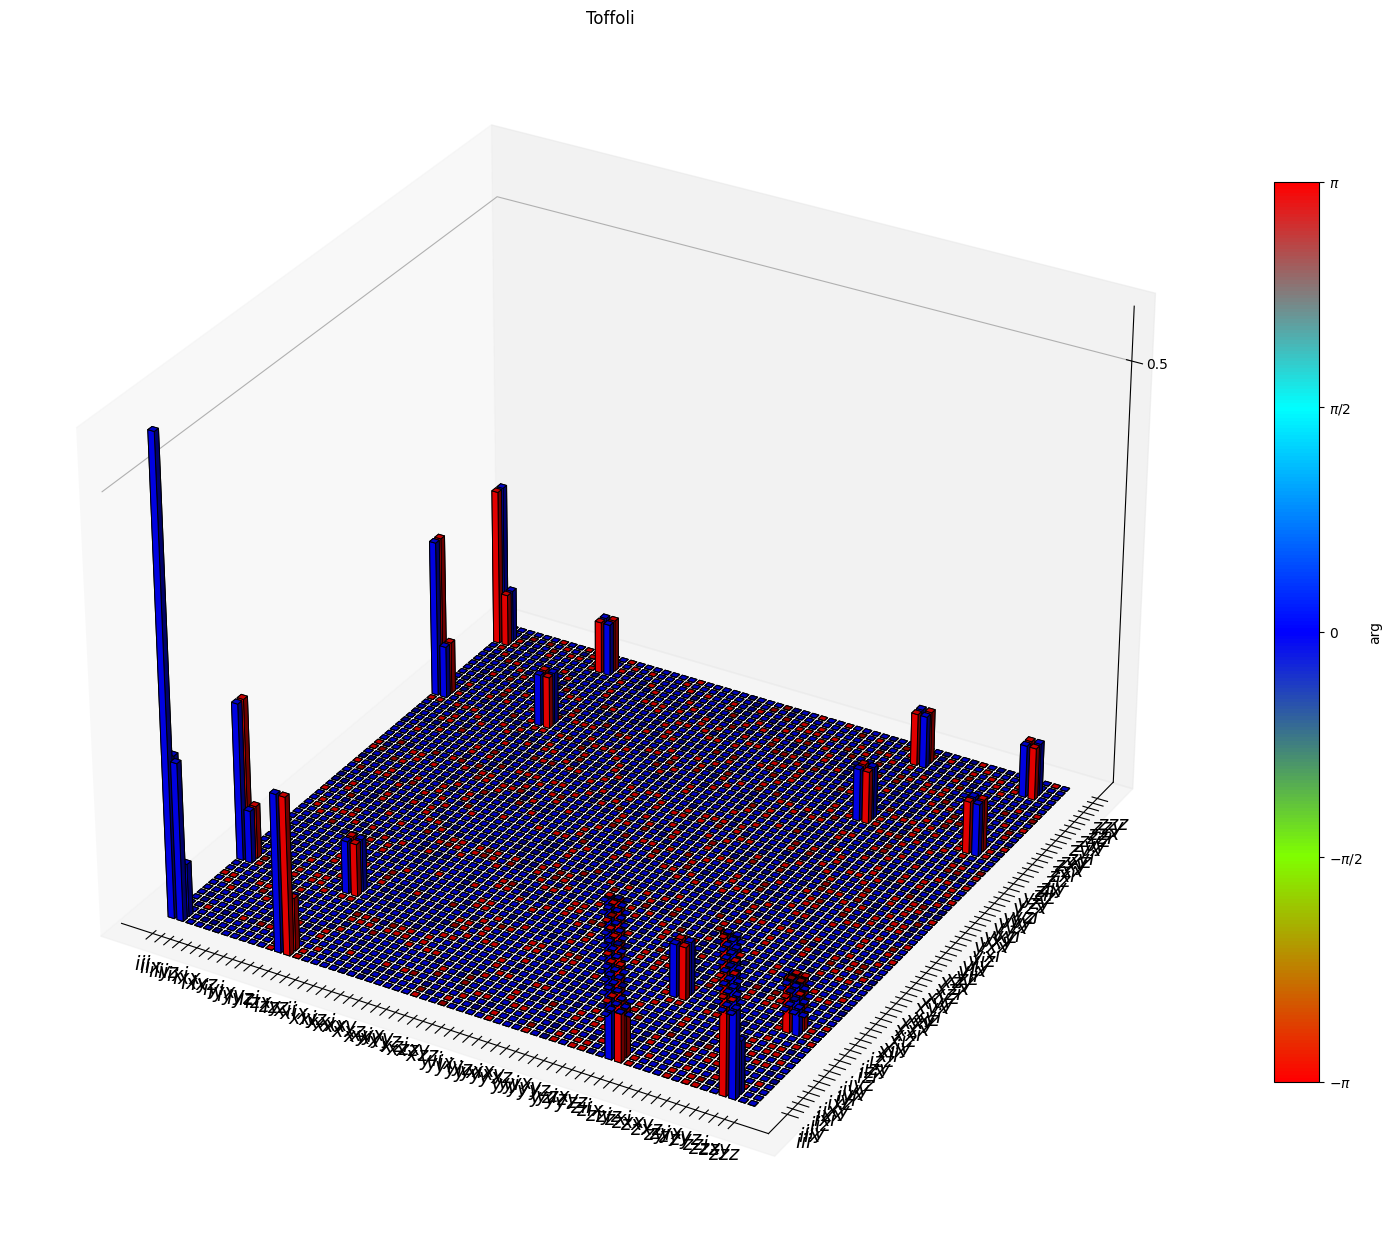

In [36]:
fig, ax = plt_qpt_gate(gates[6], figsize=(16, 12))
ax.axis("tight");

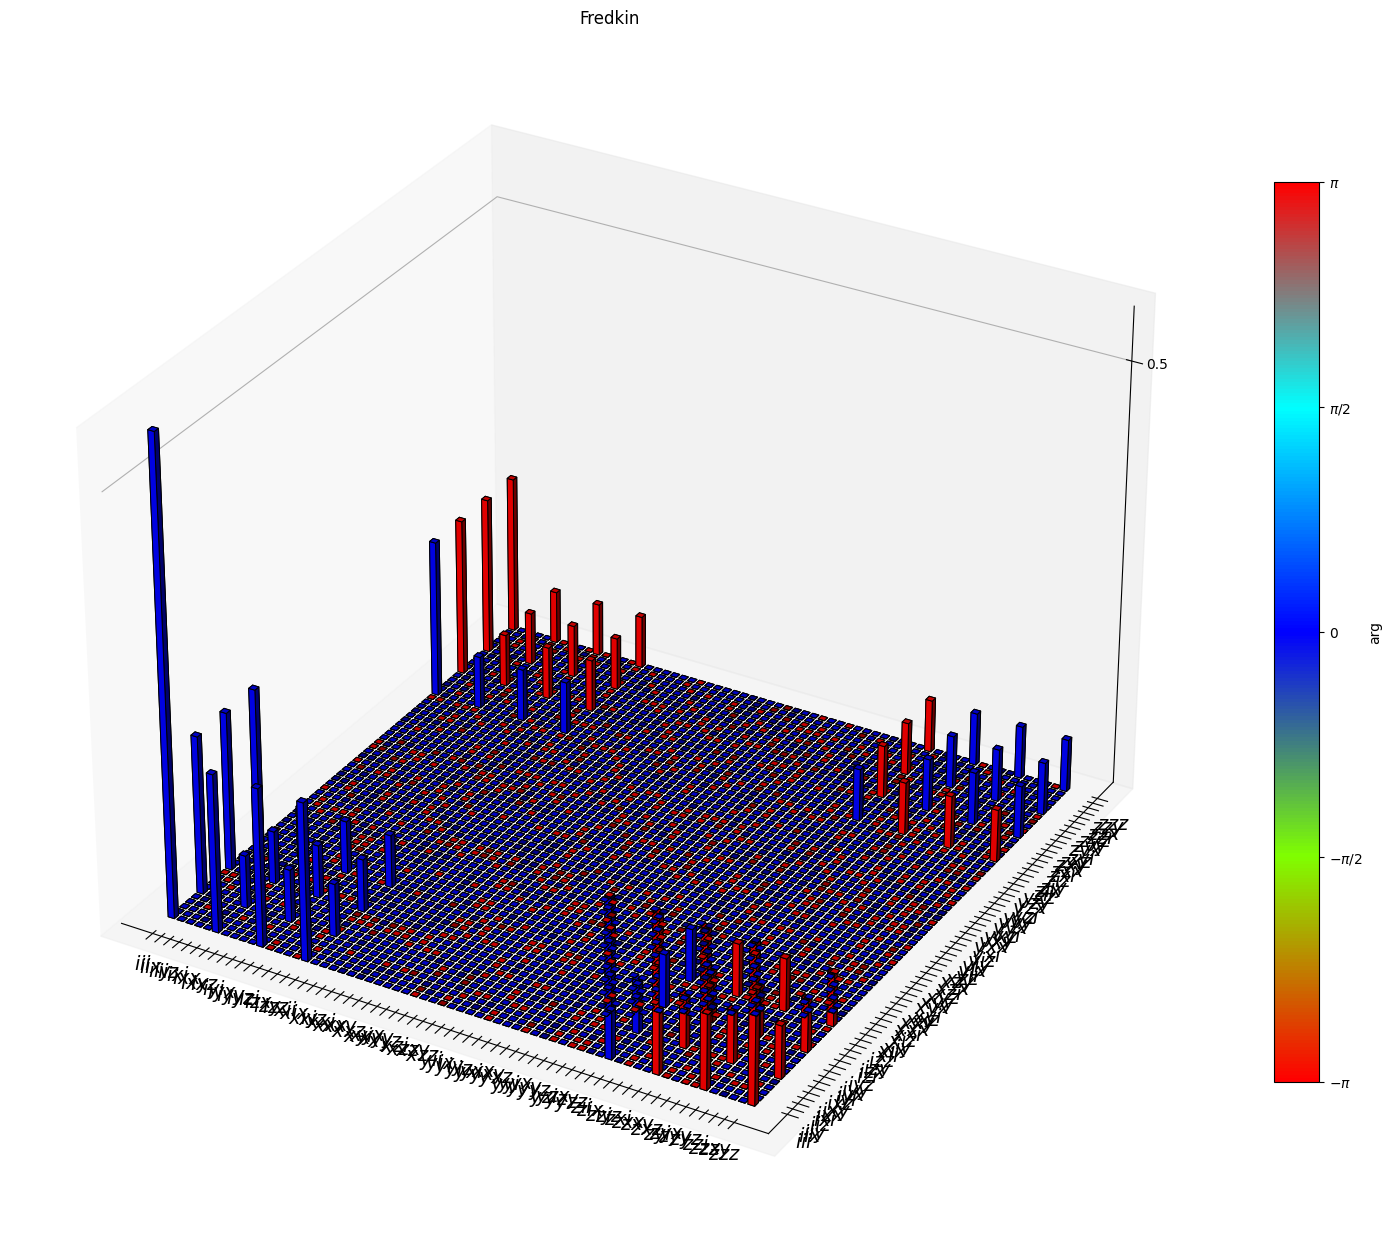

In [37]:
fig, ax = plt_qpt_gate(gates[7], figsize=(16, 12))
ax.axis("tight");